In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

%matplotlib inline

In [24]:
df = pd.read_csv("human_behavior_detection_dataset.csv")

In [25]:
X = df.drop("behavior_class", axis=1)

In [26]:
X = pd.get_dummies(X)

In [27]:
X.head()

,participant_id,age,bmi,heart_rate_bpm,skin_temperature_c,spo2_percent,respiratory_rate,steps_count,movement_speed_kmh,gesture_count,...,posture_Walking,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,location_type_Gym,location_type_Home,location_type_Indoor,location_type_Office,location_type_Outdoor
0,1,42,26.965636,73,36.959704,94,17,10993,2.157587,2,...,False,False,False,True,False,False,False,False,True,False
1,2,63,26.139501,67,35.878536,96,17,12596,3.160959,4,...,True,False,False,True,False,True,False,False,False,False
2,3,51,27.681699,95,37.488057,95,21,10751,1.403280,36,...,True,False,False,True,False,True,False,False,False,False
3,4,25,30.421866,56,36.303045,97,16,15007,3.644235,36,...,False,False,False,False,True,False,False,False,True,False
4,5,18,24.237081,61,36.520837,99,18,15041,4.518753,22,...,True,False,False,False,True,False,True,False,False,False


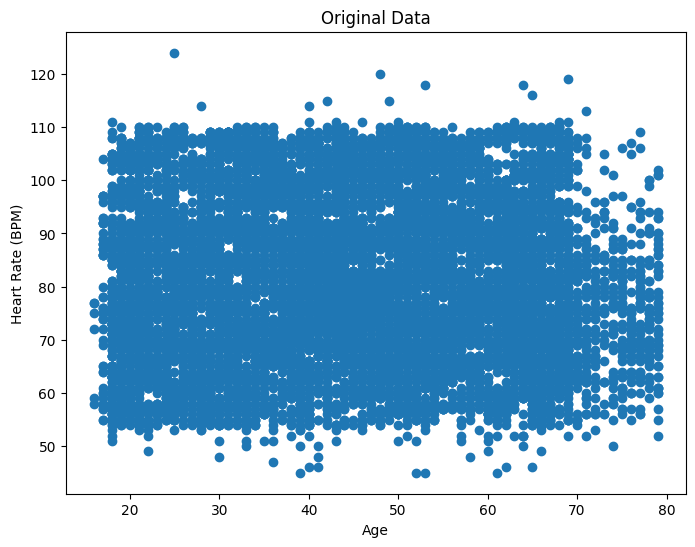

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(df['age'], df['heart_rate_bpm'])

plt.xlabel("Age")
plt.ylabel("Heart Rate (BPM)")

plt.title("Original Data")

plt.show()

In [29]:
km = KMeans(
    n_clusters=3,
    random_state=42
)

y_predicted = km.fit_predict(X)

In [30]:
df['cluster'] = y_predicted

df.head()

,participant_id,age,gender,bmi,heart_rate_bpm,skin_temperature_c,spo2_percent,respiratory_rate,steps_count,activity_level,...,reaction_time_ms,mood_score,behavior_class,hydration_ml,calories_burned,sedentary_minutes,hrv_ms,day_of_week,weather_condition,cluster
0,1,42,Female,26.965636,73,36.959704,94,17,10993,Light,...,284,7,Active,1963,602.0,406,62.3,0,0,0
1,2,63,Male,26.139501,67,35.878536,96,17,12596,Sedentary,...,160,8,Active,2093,784.9,469,40.4,1,2,0
2,3,51,Male,27.681699,95,37.488057,95,21,10751,Vigorous,...,568,2,Active,1991,614.2,260,57.8,5,1,0
3,4,25,Male,30.421866,56,36.303045,97,16,15007,Light,...,246,1,Active,2239,807.5,519,45.8,5,3,0
4,5,18,Male,24.237081,61,36.520837,99,18,15041,Sedentary,...,302,3,Moderate,1353,859.0,537,20.7,2,2,0


In [31]:
km.cluster_centers_

array([[ 5.54974497e+03,  4.38686731e+01,  2.44526127e+01,
         8.30420168e+01,  3.65828882e+01,  9.65509087e+01,
         1.66499902e+01,  1.39967991e+04,  4.20332894e+00,
         2.62384209e+01,  5.89145984e+01,  5.14784444e+02,
         7.07312078e+00,  5.98608230e+00,  9.42192691e+00,
         4.92945085e+00,  2.35393981e+02,  6.56753957e+01,
         3.64994919e+02,  4.82606996e+00,  2.15123295e+03,
         7.59495935e+02,  4.12720735e+02,  5.08222201e+01,
         2.98436584e+00,  1.01016220e+00,  5.31756889e-01,
         4.68243111e-01,  2.13015439e-02,  2.72425249e-01,
         2.01289818e-02,  2.36466680e-02,  2.39202658e-01,
         2.56986516e-01,  2.18878249e-02,  1.44420559e-01,
         2.35684972e-01,  2.69493844e-01,  2.46628884e-01,
         2.48192300e-01,  2.44674614e-01,  2.59722494e-01,
         2.43111198e-01,  2.52491694e-01,  2.26499902e-01,
         2.67344147e-01,  2.46238030e-02,  2.39398085e-01,
         2.42134063e-01],
       [ 1.02758742e+04,  4.67

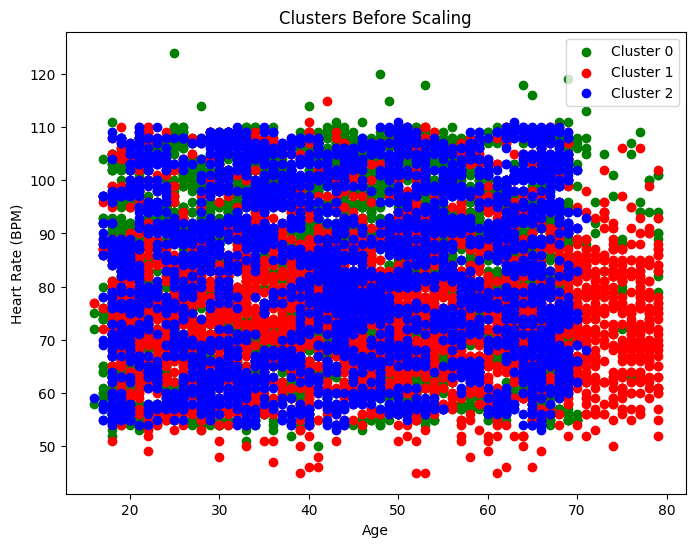

In [32]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.figure(figsize=(8,6))

plt.scatter(df1['age'], df1['heart_rate_bpm'], color='green', label='Cluster 0')

plt.scatter(df2['age'], df2['heart_rate_bpm'], color='red', label='Cluster 1')

plt.scatter(df3['age'], df3['heart_rate_bpm'], color='blue', label='Cluster 2')

plt.xlabel("Age")
plt.ylabel("Heart Rate (BPM)")

plt.legend()

plt.title("Clusters Before Scaling")

plt.show()

In [33]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [34]:
km = KMeans(
    n_clusters=3,
    random_state=42
)

y_predicted = km.fit_predict(X_scaled)

In [35]:
df['cluster'] = y_predicted

df.head()

,participant_id,age,gender,bmi,heart_rate_bpm,skin_temperature_c,spo2_percent,respiratory_rate,steps_count,activity_level,...,reaction_time_ms,mood_score,behavior_class,hydration_ml,calories_burned,sedentary_minutes,hrv_ms,day_of_week,weather_condition,cluster
0,1,42,Female,26.965636,73,36.959704,94,17,10993,Light,...,284,7,Active,1963,602.0,406,62.3,0,0,0
1,2,63,Male,26.139501,67,35.878536,96,17,12596,Sedentary,...,160,8,Active,2093,784.9,469,40.4,1,2,1
2,3,51,Male,27.681699,95,37.488057,95,21,10751,Vigorous,...,568,2,Active,1991,614.2,260,57.8,5,1,1
3,4,25,Male,30.421866,56,36.303045,97,16,15007,Light,...,246,1,Active,2239,807.5,519,45.8,5,3,1
4,5,18,Male,24.237081,61,36.520837,99,18,15041,Sedentary,...,302,3,Moderate,1353,859.0,537,20.7,2,2,1


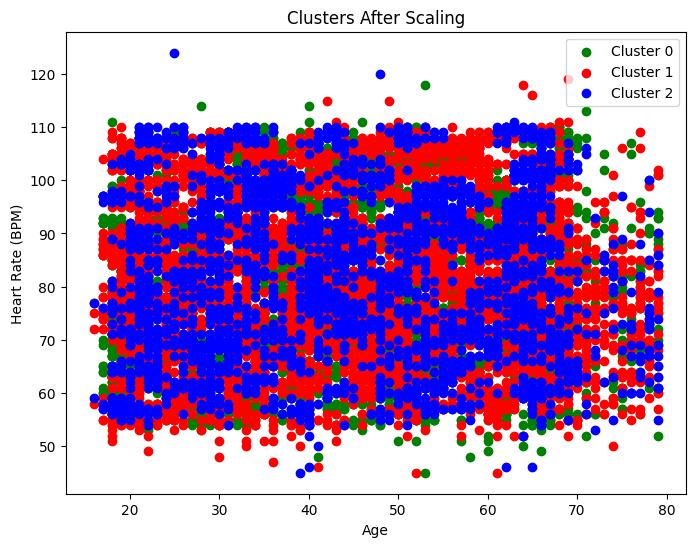

In [36]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.figure(figsize=(8,6))

plt.scatter(df1['age'], df1['heart_rate_bpm'], color='green', label='Cluster 0')

plt.scatter(df2['age'], df2['heart_rate_bpm'], color='red', label='Cluster 1')

plt.scatter(df3['age'], df3['heart_rate_bpm'], color='blue', label='Cluster 2')

plt.xlabel("Age")
plt.ylabel("Heart Rate (BPM)")

plt.legend()

plt.title("Clusters After Scaling")

plt.show()

In [37]:
sse = []

k_rng = range(1, 10)

for k in k_rng:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_scaled)

    sse.append(km.inertia_)

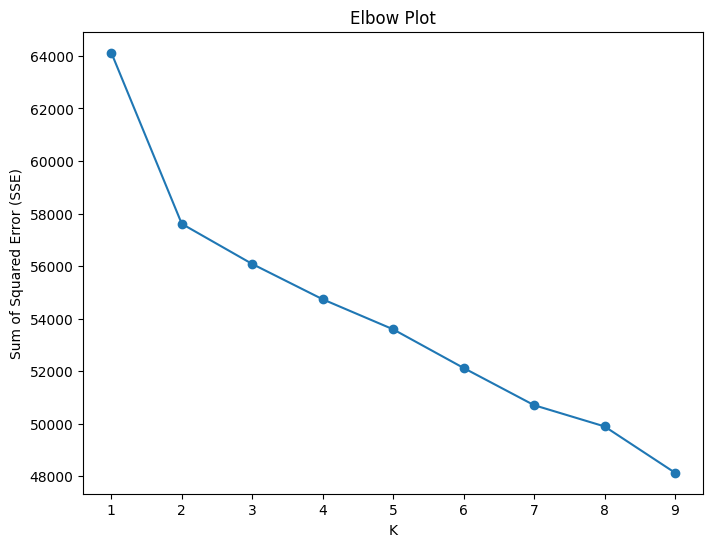

In [38]:
plt.figure(figsize=(8,6))

plt.plot(k_rng, sse, marker='o')

plt.xlabel("K")
plt.ylabel("Sum of Squared Error (SSE)")

plt.title("Elbow Plot")

plt.show()

### Evaluating K-Means

Since K-Means is an **unsupervised** clustering algorithm, it does not use the target labels (`behavior_class`) during training. It just grouped the data into 3 clusters based on patterns. 

However, since we *do* have true labels, we can measure an "accuracy" by mapping each cluster to the most frequent actual class inside that cluster. We can also look at the **Silhouette Score**, which is a standard metric for evaluating clustering quality (scale of -1 to 1).

In [39]:
import numpy as np
from sklearn.metrics import accuracy_score, silhouette_score

# Encode the true labels to numbers
y_true = LabelEncoder().fit_transform(df['behavior_class'])

# Map each cluster (0, 1, 2) to the most frequent true class inside that cluster
mapped_labels = np.zeros_like(y_predicted)
for i in range(3):
    mask = (y_predicted == i)
    if np.sum(mask) > 0:
        most_frequent_class = np.bincount(y_true[mask]).argmax()
        mapped_labels[mask] = most_frequent_class

accuracy = accuracy_score(y_true, mapped_labels)
print(f"Mapped K-Means Accuracy: {accuracy:.4f}")

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, y_predicted)
print(f"Silhouette Score: {sil_score:.4f}")

Mapped K-Means Accuracy: 0.4438
Silhouette Score: 0.0659
